In [99]:
import pandas as pd
import numpy as np

df = pd.read_csv('DA_clean.csv')

drop_cols = [
    'Item_Identifier',
    'Outlet_Identifier',
    'Outlet_Establishment_Year'
]

df_model = df.drop(columns=drop_cols)

df_model.head()

,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales,Item_Category,Outlet_Years
0,9.30,Low Fat,0.016047,Dairy,249.8092,Medium,Tier 1,Supermarket Type1,3735.1380,Food,14
1,5.92,Regular,0.019278,Soft Drinks,48.2692,Medium,Tier 3,Supermarket Type2,443.4228,Drinks,4
2,17.50,Low Fat,0.016760,Meat,141.6180,Medium,Tier 1,Supermarket Type1,2097.2700,Food,14
3,19.20,Regular,0.073719,Fruits and Vegetables,182.0950,Small,Tier 3,Grocery Store,732.3800,Food,15
4,8.93,Non-Edible,0.064963,Household,53.8614,High,Tier 3,Supermarket Type1,994.7052,Non-Consumable,26


ENCODING

In [100]:
# One Hot Encoding
df_model = pd.get_dummies(df_model, drop_first=True)

df_model.head()

# Buat download encoded dataset
# df_model.to_csv('DA_model_ready.csv', index=False)

,Item_Weight,Item_Visibility,Item_MRP,Item_Outlet_Sales,Outlet_Years,Item_Fat_Content_Non-Edible,Item_Fat_Content_Regular,Item_Type_Breads,Item_Type_Breakfast,Item_Type_Canned,...,Item_Type_Starchy Foods,Outlet_Size_Medium,Outlet_Size_Small,Outlet_Location_Type_Tier 2,Outlet_Location_Type_Tier 3,Outlet_Type_Supermarket Type1,Outlet_Type_Supermarket Type2,Outlet_Type_Supermarket Type3,Item_Category_Food,Item_Category_Non-Consumable
0,9.30,0.016047,249.8092,3735.1380,14,False,False,False,False,False,...,False,True,False,False,False,True,False,False,True,False
1,5.92,0.019278,48.2692,443.4228,4,False,True,False,False,False,...,False,True,False,False,True,False,True,False,False,False
2,17.50,0.016760,141.6180,2097.2700,14,False,False,False,False,False,...,False,True,False,False,False,True,False,False,True,False
3,19.20,0.073719,182.0950,732.3800,15,False,True,False,False,False,...,False,False,True,False,True,False,False,False,True,False
4,8.93,0.064963,53.8614,994.7052,26,True,False,False,False,False,...,False,False,False,False,True,True,False,False,False,True


In [101]:
#feature selection
X = df_model.drop('Item_Outlet_Sales', axis=1)
y = df_model['Item_Outlet_Sales']

SCALING

In [102]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [103]:
#Train test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

LINEAR REGRESSION MODEL

In [104]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

LinearRegression()

In [105]:
#Prediction
lr_pred = lr_model.predict(X_test)

LR EVALUATION

In [106]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

lr_mae = mean_absolute_error(y_test, lr_pred)
lr_mse = mean_squared_error(y_test, lr_pred)
lr_rmse = np.sqrt(lr_mse)
lr_r2 = r2_score(y_test, lr_pred)

print("Linear Regression MAE :", lr_mae)
print("Linear Regression RMSE :", lr_rmse)
print("Linear Regression R2 :", lr_r2)

Linear Regression MAE : 792.551180574202
Linear Regression RMSE : 1069.916087144817
Linear Regression R2 : 0.5788325825986002


RANDOM FOREST

In [107]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestRegressor(max_depth=20, min_samples_leaf=2, min_samples_split=5,
                      n_estimators=300, random_state=42)

In [108]:
#RF Predict
rf_pred = rf_model.predict(X_test)

RF EVALUATION

In [109]:
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_mse = mean_squared_error(y_test, rf_pred)
rf_rmse = np.sqrt(rf_mse)
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest MAE :", rf_mae)
print("Random Forest RMSE :", rf_rmse)
print("Random Forest R2 :", rf_r2)

Random Forest MAE : 750.1630043440013
Random Forest RMSE : 1072.942777668563
Random Forest R2 : 0.5764463272459321


XGBOOST

In [110]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

In [111]:
# XGBoost Predict
xgb_pred = xgb_model.predict(X_test)

XB EVALUATION

In [112]:
xgb_mae = mean_absolute_error(y_test, xgb_pred)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))
xgb_r2 = r2_score(y_test, xgb_pred)

print("XGBoost MAE :", xgb_mae)
print("XGBoost RMSE :", xgb_rmse)
print("XGBoost R2 :", xgb_r2)

XGBoost MAE : 746.262390952656
XGBoost RMSE : 1076.2884907054488
XGBoost R2 : 0.5738007090464526


GRADIENTBOOST

In [113]:
from sklearn.ensemble import GradientBoostingRegressor

gbr_model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)

gbr_model.fit(X_train, y_train)

# GradientBoost Predict
gbr_pred = gbr_model.predict(X_test)

GB EVALUATION

In [114]:
gbr_mae = mean_absolute_error(y_test, gbr_pred)
gbr_rmse = np.sqrt(mean_squared_error(y_test, gbr_pred))
gbr_r2 = r2_score(y_test, gbr_pred)

print("GBR MAE :", gbr_mae)
print("GBR RMSE :", gbr_rmse)
print("GBR R2 :", gbr_r2)

GBR MAE : 733.0999686463367
GBR RMSE : 1044.9499431014167
GBR R2 : 0.5982588634808418


CATBOOST REGRESSOR

In [115]:
!pip install catboost

In [116]:
from catboost import CatBoostRegressor

cat_model = CatBoostRegressor(
    iterations=300,
    learning_rate=0.05,
    depth=6,
    verbose=0,
    random_state=42
)

cat_model.fit(X_train, y_train)

CatBoostRegressor(depth=6, iterations=300, learning_rate=0.05, loss_function='RMSE', random_state=42, verbose=0)

In [117]:
# CatBoost Predict
cat_pred = cat_model.predict(X_test)

CB EVALUATION

In [118]:
cat_mae = mean_absolute_error(y_test, cat_pred)
cat_rmse = np.sqrt(mean_squared_error(y_test, cat_pred))
cat_r2 = r2_score(y_test, cat_pred)

print("CatBoost MAE :", cat_mae)
print("CatBoost RMSE :", cat_rmse)
print("CatBoost R2 :", cat_r2)

CatBoost MAE : 719.081714435107
CatBoost RMSE : 1028.872731502153
CatBoost R2 : 0.6105258440368326


EVALUATION - COMPARE MODELS

In [120]:
comparison = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Random Forest',
        'XGBoost',
        'GradientBoost',
        'CatBoost'
    ],

    'R2 Score': [
        lr_r2,
        rf_r2,
        xgb_r2,
        gbr_r2,
        cat_r2
    ],

    'RMSE': [
        lr_rmse,
        rf_rmse,
        xgb_rmse,
        gbr_rmse,
        cat_rmse
    ],

    'MAE': [
        lr_mae,
        rf_mae,
        xgb_mae,
        gbr_mae,
        cat_mae
    ]
})

comparison

,Model,R2 Score,RMSE,MAE
0,Linear Regression,0.578833,1069.916087,792.551181
1,Random Forest,0.576446,1072.942778,750.163004
2,XGBoost,0.573801,1076.288491,746.262391
3,GradientBoost,0.598259,1044.949943,733.099969
4,CatBoost,0.610526,1028.872732,719.081714


EDA AFTRER MODELLING

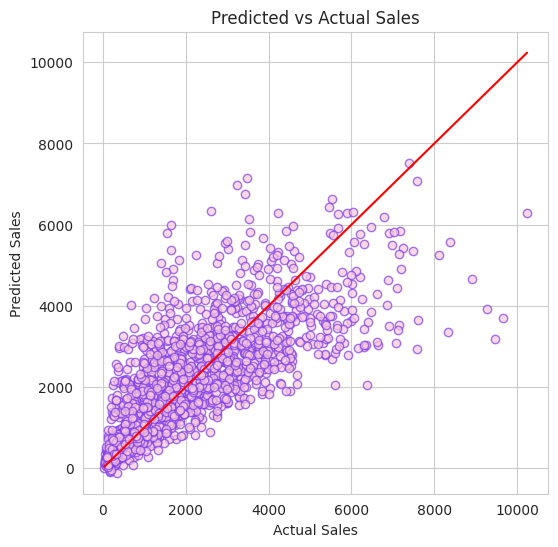

In [121]:
# PREDICTED VS ACTUAL PLOT
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

plt.figure(figsize=(6,6))

plt.scatter(
    y_test,
    xgb_pred,
    color='#F8C8DC',
    edgecolor='#7C3AED',
    alpha=0.7
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red'
)

plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.title('Predicted vs Actual Sales')

plt.show()

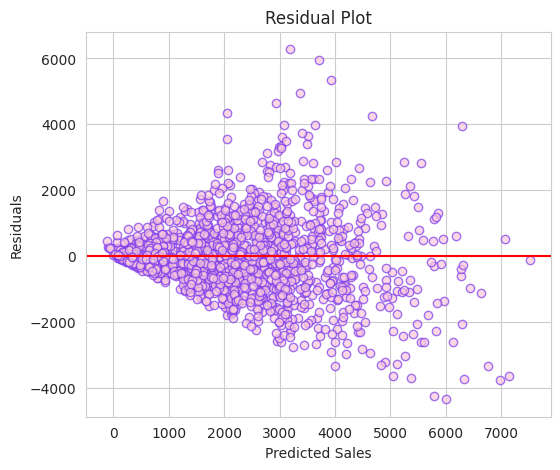

In [122]:
# RESIDUAL PLOT
residuals = y_test - xgb_pred

plt.figure(figsize=(6,5))

plt.scatter(
    xgb_pred,
    residuals,
    color='#F8C8DC',
    edgecolor='#7C3AED',
    alpha=0.7
)

plt.axhline(y=0, color='red')

plt.xlabel('Predicted Sales')
plt.ylabel('Residuals')
plt.title('Residual Plot')

plt.show()

EVALUATION - CROSS VALIDATION

In [123]:
#CROSS VALIDATION -> pake XGB karenaa
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    xgb_model,
    X_scaled,
    y,
    cv=10,
    scoring='r2'
)

print("CV Scores :", cv_scores)
print("Average CV :", cv_scores.mean())
print("Variance :", cv_scores.var())

CV Scores : [0.57272625 0.58679881 0.50443835 0.58049068 0.49180854 0.5671719
 0.57815168 0.56159684 0.59779253 0.54202626]
Average CV : 0.5583001824221347
Variance : 0.0011143080490270173
